# FACIAL AND EYE DETECTION

###  Use of Haar Cascades to detect faces in images (Deep Learning concept not used -> X)

### Haar Cascade is the key component of Viola-Jones object detection framework.

### Face Detection, Not Face Recognition

### Initially, Viola-Jones propsed the method for calculating these sums for the entire image would be very computionally expensive.
Later on, they solves this by using Integral image.(Resulting in an O(1) running time of the algorithm,)

### Integral image -> also known as a summed area table.

### In this, image is treated as a series of classifiers based on the simple features. So, instead of goining through the entire image looking for a face, we pass the cascade of the classifiers.

# Process for the Face Detection:
1. Front Facing image of person
2. Turn it to grayscale
3. Begin the search for Haar cascade Features
    (Very first features searched for is an edge feature indicating eyes and cheeks.)
4. If passed the search, then next feature such as bridge of the nose.
5. We continue through this cascade process until required feature is detected. Then we can say face is detected or not.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
nadia = cv2.imread('../DATA/Nadia_Murad.jpg', 0)
denis = cv2.imread('../DATA/Denis_Mukwege.jpg', 0)
solvay = cv2.imread('../DATA/solvay_conference.jpg', 0)

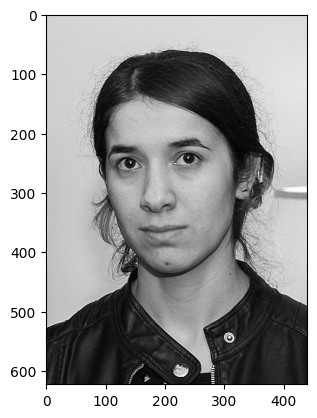

In [7]:
plt.imshow(nadia, cmap='gray')

In [10]:
face_cascade = cv2.CascadeClassifier('../DATA/haarcascades/haarcascade_frontalface_default.xml')

In [11]:
# Detecting face
def detect_face(img):
    face_img = img.copy()
    face_rects = face_cascade.detectMultiScale(face_img)

    for (x, y, w, h) in face_rects:
        cv2.rectangle(face_img, (x,y), (x+w, y+h), (255, 255, 255), 10)

    return face_img

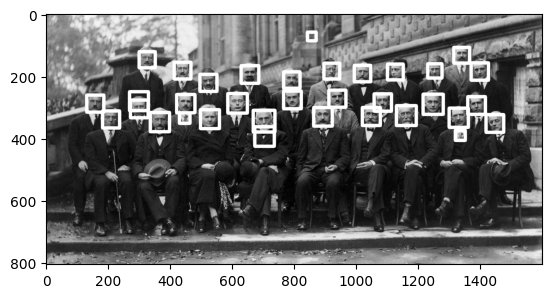

In [14]:
result = detect_face(solvay)
plt.imshow(result, cmap='gray')

In [16]:
# Adjusting detection of face
def adj_detect_face(img):
    face_img = img.copy()
    face_rects = face_cascade.detectMultiScale(face_img, scaleFactor=1.2,minNeighbors=5)

    for (x, y, w, h) in face_rects:
        cv2.rectangle(face_img, (x,y), (x+w, y+h), (255, 255, 255), 10)

    return face_img

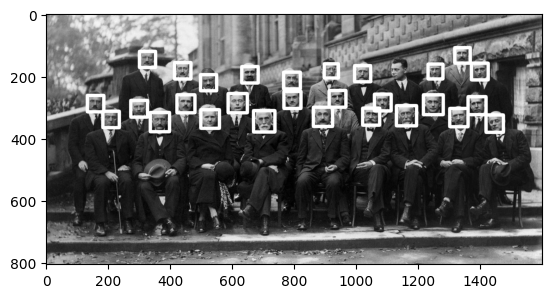

In [17]:
result = adj_detect_face(solvay)
plt.imshow(result, cmap='gray')

In [18]:
# Eye Detection
eye_cascade = cv2.CascadeClassifier('../DATA/haarcascades/haarcascade_eye.xml')

In [24]:
def detect_eyes(img):
    face_img = img.copy()
    eyes_rects = eye_cascade.detectMultiScale(face_img, scaleFactor=1.2,minNeighbors=5)

    for (x, y, w, h) in eyes_rects:
        cv2.rectangle(face_img, (x,y), (x+w, y+h), (255, 255, 255), 10)

    return face_img

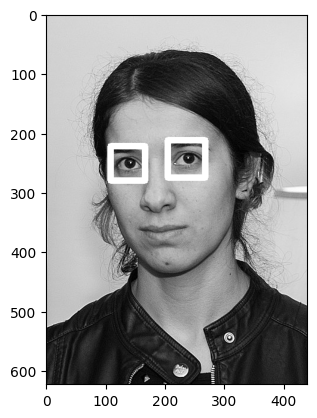

In [25]:
result = detect_eyes(nadia)
plt.imshow(result, cmap='gray')

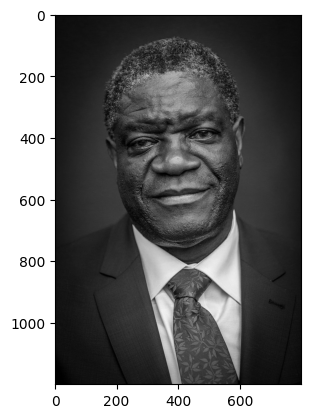

In [27]:
result = detect_eyes(denis)
plt.imshow(result, cmap='gray')
# Not able to detect the eye of denis, reason being the white area(cornea) is a bit dim in color because of the editing done of the picture.

In [28]:
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read(0)
    frame = detect_face(frame)
    cv2.imshow('Video Face Detect', frame)

    k = cv2.waitKey(1)
    if k == 27:
        break

cap.release()
cv2.destroyAllWindows()

### ASSESSMENT

In [33]:
car_plate = cv2.imread('../DATA/car_plate.jpg')

In [36]:
def display(img, cmap='gray'):
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap='gray')

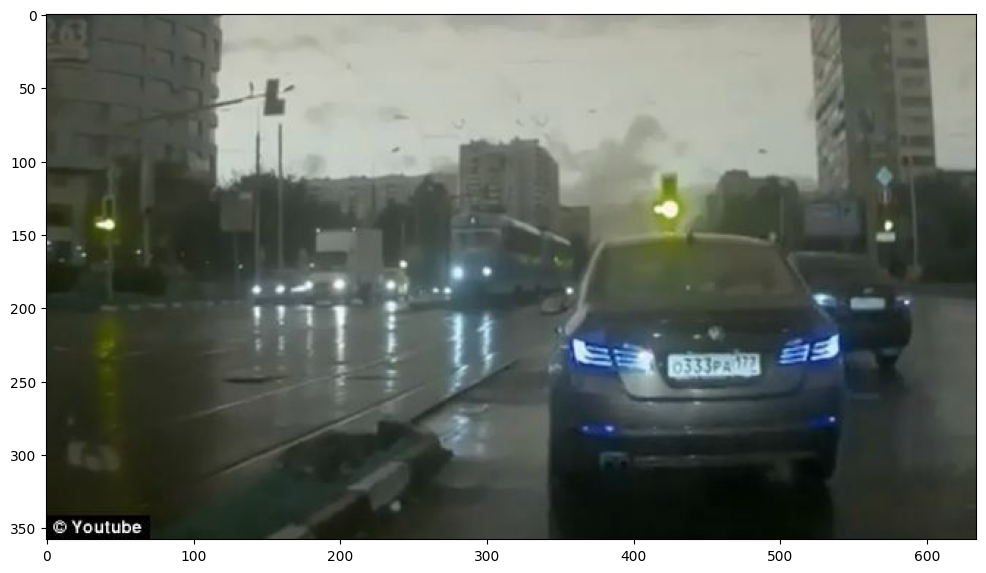

In [37]:
display(car_plate)

In [38]:
russian_plate_cascade = cv2.CascadeClassifier('../DATA/haarcascades/haarcascade_russian_plate_number.xml')

In [47]:
def detect_plate(img):
    car_plate_image = img.copy()
    plate_rects = russian_plate_cascade.detectMultiScale(car_plate_image, scaleFactor=1.2,minNeighbors=5)

    for (x, y, w, h) in plate_rects:
        cv2.rectangle(car_plate_image, (x,y), (x+w, y+h), (255, 0, 0), 4)

    return car_plate_image

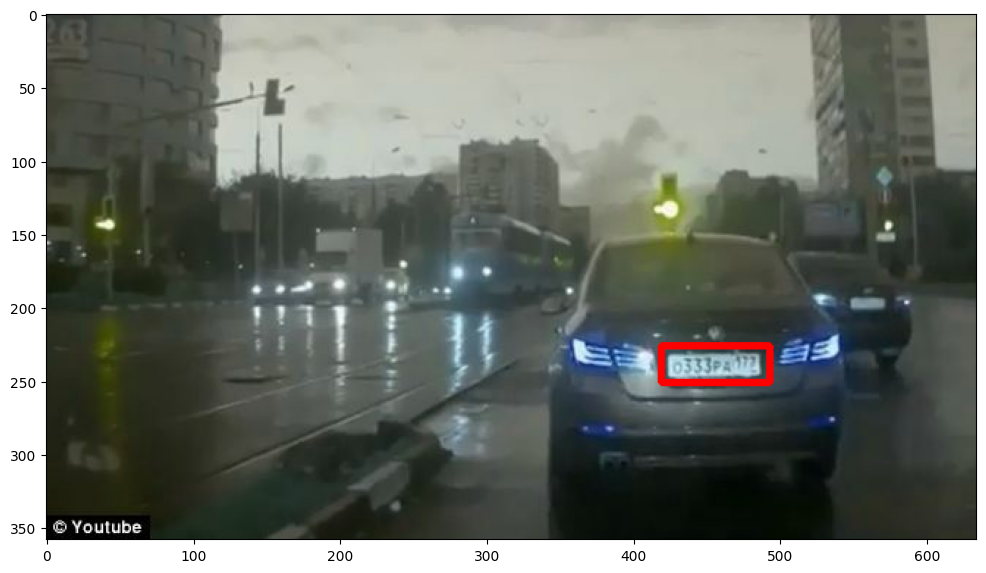

In [48]:
result = detect_plate(car_plate)
display(result)

In [56]:
# Now blurring the detected plate
def detect_and_blur_plate(img):
    plate_img = img.copy()
    roi = img.copy()

    plate_rects = russian_plate_cascade.detectMultiScale(plate_img, scaleFactor=1.2,minNeighbors=5)

    for (x,y,w,h) in plate_rects:
        # slicing dimentions for the plate
        roi = roi[y:y+h, x:x+w]
        blurred_roi = cv2.medianBlur(roi, 7) # (image, kernel)

        plate_img[y:y+h, x:x+w] = blurred_roi

    return plate_img

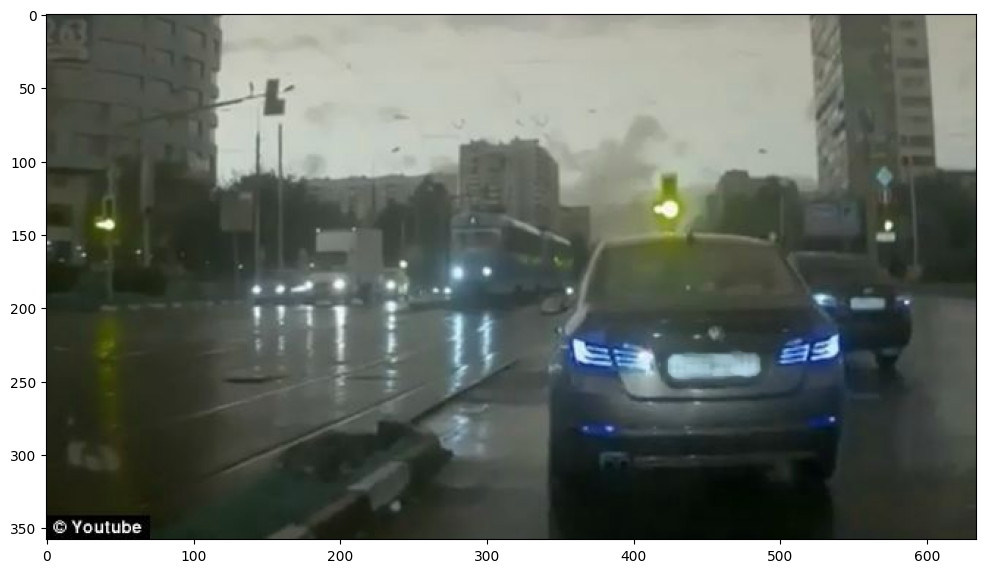

In [57]:
result = detect_and_blur_plate(car_plate)
display(result)

In [58]:
# Car plate is blurred now.